# 🧭 Modelling Strategy
### **Goals:**
* Avoid data leakage
* Handle known operational anomalies (e.g. bad CN supply, poor oxygenation)
* Prioritise interpretability and physical plausibility
* Prepare for hybrid (kinetic + ML) modelling

# 📚 Step 0: Import libraries & Load Data

Load core libraries for data handling, modelling, and visualisation.

In [74]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("shanta_usage_data.csv")

# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Columns: 162 entries, Date to Predicted_NaCN_Used_Mid_Corrected_kg
dtypes: bool(3), float64(154), int64(2), object(3)
memory usage: 484.5+ KB


# ⚙️ Step 1: Define constants

Set plant configuration, material properties, modelling parameters, and economic assumptions.

In [75]:
# Feed charateristics
ultrafine_sizing = 50	 							# midpoint for < 75 µm sizing
fine_sizing = 112.5									# midpoint for > 75 µm sizing
coarse_sizing = 175 								# midpoint for > 150 µm sizing

# 🛠️ Step 2: Establish Feratures & Interaction Terms
* Remove known corrupt or anomalous periods (e.g. poor CN supply in early 2024)
* Define candidate features including raw, engineered, and interaction terms
* Confirm targets: Au_Recovery_pct, CN_Consumption, and Tailings_CN_ppm

In [ ]:
# --- Calculate an average particle size for the feed ---
size_sum = (
	df["Leach_Feed_Lt_75um_Day"] +
	df["Leach_Feed_Gt_75um_Day"] +
	df["Leach_Feed_Gt_150um_Day"]
)
df["Particle_Size"] = (
	df["Leach_Feed_Lt_75um_Day"] * ultrafine_sizing +
	df["Leach_Feed_Gt_75um_Day"] * fine_sizing +
	df["Leach_Feed_Gt_150um_Day"] * coarse_sizing
) / size_sum.replace(0, np.nan)

# --- Define interaction terms ---
df["Ultrafines_Fraction"] = df["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)
df["Grade_x_Ultrafines"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Ultrafines_Fraction"]
df["Grade_x_Throughput"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Leach_Feed_Throughput_M3Day"]
df["Grade_x_Tons"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Daily_Milledtreated_Tons"]
df["Grade_x_Ultrafines_Sqrt"] = np.sqrt(df["Grade_x_Ultrafines"])
max_val = df["Grade_x_Ultrafines_Sqrt"].quantile(0.95)
df["Gold_Liberation"] = df["Grade_x_Ultrafines_Sqrt"] / max_val
df["Gold_Liberation"] = df["Gold_Liberation"].clip(0, 1)


# --- Calculate historical CN consumption--- 
# Convert % solids to fractional solids
df["Solids_Fraction"] = df["Percentsolids"] / 100
df["Liquid_Fraction"] = 1 - df["Solids_Fraction"]

# Calculate Wet mass of slurry (kg)
df["Slurry_Mass_Kg"] = df["Daily_Milledtreated_Tons"] * 1000 / df["Solids_Fraction"]

# Calculate Liquid mass in slurry (assuming water ~1kg/L)
df["Solution_Mass_Kg"] = df["Slurry_Mass_Kg"] * df["Liquid_Fraction"]

df["Calc_NaCN_Used_Kg"] = df["Leach_Cn_Adds_ppm"] * df["Solution_Mass_Kg"] / 1e6

# Group by month and sum both calculated and actual NaCN usage
monthly_balance = df.groupby("Month").agg({
	"Calc_NaCN_Used_Kg": "sum",
	"NaCN_Used_Kg": "sum"
}).reset_index()

monthly_scaling = (
	monthly_balance["Calc_NaCN_Used_Kg"].sum() /
	monthly_balance["NaCN_Used_Kg"].sum()
)

# Apply the global scaling factor to the daily-level estimate
df["Daily_NaCN_Used_Kg"] = df["Calc_NaCN_Used_Kg"] * monthly_scaling
# Calculate Daily_NaCN_ppm
df["Daily_NaCN_ppm"] = df["Daily_NaCN_Used_Kg"] / df["Solution_Mass_Kg"] * 1e6

# --- Rename columns for clarity ---
df.rename(columns={
	"Daily_NaCN_ppm": "CN",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": "DO",
	"Leach_Feed_Grade_Au_Gt_Day": "Grade",
	"Au_Recovery": "Recovery",
	"Leach_Feed_Lt_75um_Day": "Ultrafines",
	"Leach_Feed_Gt_75um_Day": "Fines",
	"Leach_Feed_Gt_150um_Day": "Coarse",
}, inplace=True)

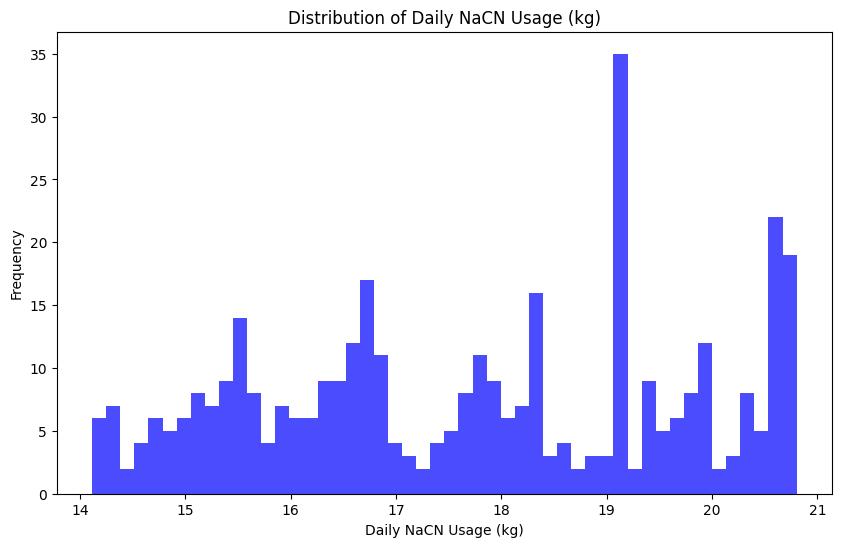

In [77]:
# Plot distribution of Daily_NaCN_Used_Kg
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df["DO"], bins=50, color='blue', alpha=0.7)
plt.title("Distribution of Daily NaCN Usage (kg)")
plt.xlabel("Daily NaCN Usage (kg)")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

In [78]:
df.columns.to_list()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Grade',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Coarse',
 'Fines',
 'Ultrafines',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01',
 'Dissolved_Oxygen_Profile_Ppm_Leach_

# Step 3: Kinetic Model

#### Inputs required for the Kinetic Model
| Variable       | Expected Unit         | Explanation                                                                                                                         |
| -------------- | --------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **CN**         | **mg/L** or **ppm**   | These are equivalent in dilute aqueous solution (1 mg/L ≈ 1 ppm). This is the standard unit in leaching kinetics and plant control. |
| **DO**         | **mg/L** or **ppm**   | Again, ppm and mg/L are interchangeable for gases dissolved in water. Most DO sensors report in mg/L.                               |
| **Grade**      | g/t (grams per tonne) | For gold recovery calculations.                                                                                                     |
| **Recovery**   | % (0–100)             | Percent recovery of gold from ore.                                                                                                  |
| **Liberation** | fraction (0–1)        | E.g. 0.85 means 85% of gold is liberated and available for leaching.                                                                |


### Gold Liberation
The testwork from the PRELIMINARY: METALLURGICAL REPORT No: 18/679, provides the **liberation based on mineral exposure** for the New Luika test sample as follows:
* Liberated = >80% exposed gold
* Locked = <30% exposed gold
* 64% of particles in the sample are "Liberated"
* 26% are "Locked"
* 10% are in middling classes

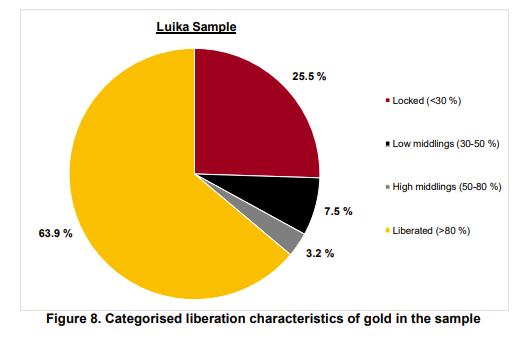

**Grain Size Data used to Guide Liberation Curve**
From **Table 8 (Gold Grain Size Distribution)**, ~80% of grains are <40 µm.

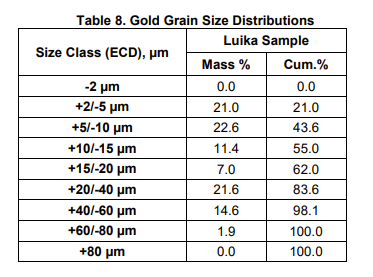

This suggests that:
* Liberation is high when particle size < 40 µm (because gold is smaller and easier to expose).
* Liberation drops as particle size increases.

### Define a Liberation Function Based on Particle Size
A smooth exponential liberation function:

In [90]:
# Define the liberation estimation function
def estimate_liberation(particle_size_um, gold_grain_size_um=40, sharpness=1, smooth=True):
	"""
	Estimate gold liberation fraction based on particle size using a smooth sigmoid curve.
	
	Parameters:
	- particle_size_um: average particle size in microns
	- gold_grain_size_um: characteristic gold grain size (default 40 µm from testwork)
	- sharpness: controls steepness of liberation curve
	
	Returns:
	- liberation factor (0 to 1)
	"""
	if smooth:
		# Use a sigmoid function for smooth transition
		liberation = 1 / (1 + (particle_size_um / gold_grain_size_um) ** sharpness)
	else:
		# Use an exponential decay for a sharper transition
		liberation = np.exp(-particle_size_um / gold_grain_size_um)
	
	return np.clip(liberation, 0, 1)

### Apply the liberation function

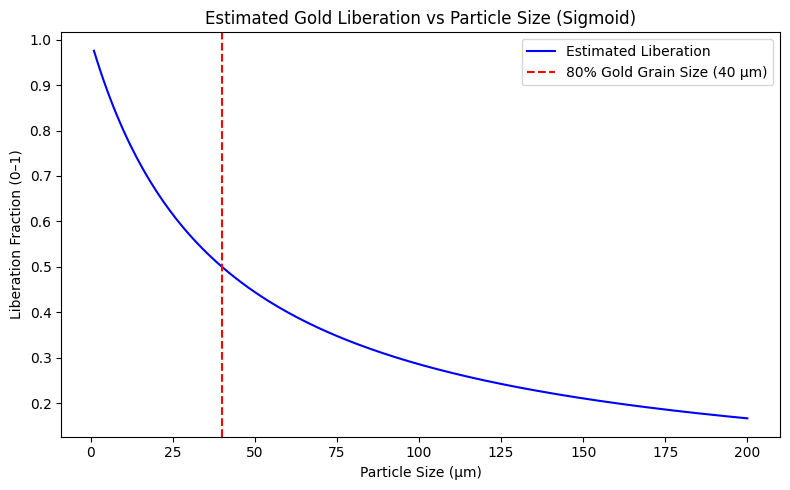

In [97]:
# Create a DataFrame to plot the liberation curve
particle_sizes = np.linspace(1, 200, 200)
liberation_values = estimate_liberation(particle_sizes)

def plot_liberation_curve(particle_sizes, liberation_values, title):
    """
    Plot the liberation curve based on particle size.
    
    Parameters:
    - particle_sizes: array of particle sizes in microns
    - liberation_values: estimated liberation values (0 to 1)
    """
    plt.figure(figsize=(8, 5))
    plt.plot(particle_sizes, liberation_values, label="Estimated Liberation", color='blue')
    plt.axvline(40, color='red', linestyle='--', label='80% Gold Grain Size (40 µm)')
    plt.title(title)
    plt.xlabel("Particle Size (µm)")
    plt.ylabel("Liberation Fraction (0–1)")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot liberation vs particle size - using a smooth curve (sigmoid)
plot_liberation_curve(particle_sizes, liberation_values,
                      "Estimated Gold Liberation vs Particle Size (Sigmoid)")

The plot shows an exponentially decreasing liberation as particle size increases, using:
* **Characteristic gold grain size** = 40 µm (from Table 8)
* At 40 µm, liberation is ~50%
* At <20 µm, liberation approaches 100%
* At >120 µm, liberation drops below 25%

### Apply It to Particle Size Distribution
This produces a **composite liberation factor** (0–1) based on the actual blend and known size-liberation relationship.

In [107]:
# Calculate mean coarse, fine, and ultrafine values from the DataFrame
ultrafines_pct = df["Ultrafines"].mean()
fines_pct = df["Fines"].mean()
coarse_pct = df["Coarse"].mean()

def compute_weighted_liberation(ultra_pct, fine_pct, coarse_pct, 
                                 sizes=[ultrafine_sizing, fine_sizing, coarse_sizing], gold_grain_size=40):
    lib_u = estimate_liberation(sizes[0], gold_grain_size)
    lib_f = estimate_liberation(sizes[1], gold_grain_size)
    lib_c = estimate_liberation(sizes[2], gold_grain_size)

    liberation = (ultra_pct * lib_u + fine_pct * lib_f + coarse_pct * lib_c) / 100
    return liberation

composite_liberation = compute_weighted_liberation(ultrafines_pct, fines_pct, coarse_pct)

print(f"Composite Liberation: {composite_liberation * 100:.1f}% for particle sizes of\n"
      f"Ultrafines: {ultrafines_pct:.2f}% @ 50µm\nFines: {fines_pct:.2f}% @ 115µm\n"
      f"Coarse: {coarse_pct:.2f}% @ 150µm\n")

Composite Liberation: 38.7% for particle sizes of
Ultrafines: 72.68% @ 50µm
Fines: 17.38% @ 115µm
Coarse: 9.87% @ 150µm



#### 🧠 Interpretation:
Consistent with mineralogical report showing:
* A mix of liberated and locked particles.
* Most gold likely resides in finer particles.

The liberation estimate can now be added as a row-wise field (Gold_Liberation) for use in the kinetic leach model.

In [109]:
# Apply liberation calculation row-wise
def calculate_row_liberation(row):
    return compute_weighted_liberation(
        row["Ultrafines"],
        row["Fines"],
        row["Coarse"],
        sizes=[ultrafine_sizing, fine_sizing, coarse_sizing],
        gold_grain_size=40
    )

df["Gold_Liberation"] = df.apply(calculate_row_liberation, axis=1)

df[["Coarse", "Fines", "Ultrafines", "Gold_Liberation"]].head(-10)

,Coarse,Fines,Ultrafines,Gold_Liberation
0,15.655000,22.020000,65.858692,0.379588
1,15.245000,19.400000,62.117668,0.355327
2,15.130000,19.180000,64.551262,0.365352
3,16.130000,21.575000,62.579023,0.364728
4,18.500000,21.265000,59.298338,0.353744
...,...,...,...,...
318,6.935913,17.475470,78.588617,0.408024
319,3.029663,8.805843,77.920000,0.375045
320,6.897116,21.188629,74.914254,0.401361
321,6.457866,17.938427,78.603707,0.408416


In [ ]:
def prepare_kinetic_model_inputs(df):
    """
    Prepares required fields for kinetic leach modelling including:
    - Liberation estimate based on particle size distribution
    - Gold available (unlocked)
    - Residence time
    - Average particle size

    Parameters:
    - df (pd.DataFrame): Input process data

    Returns:
    - pd.DataFrame: Enhanced dataframe with added fields
    """
    # --- Helper: Liberation estimation ---
    def estimate_liberation(particle_size_um, gold_grain_size_um=40, sharpness=1):
        liberation = 1 / (1 + (particle_size_um / gold_grain_size_um) ** sharpness)
        return np.clip(liberation, 0, 1)

    def compute_weighted_liberation(ultra_pct, fine_pct, coarse_pct, 
                                     sizes=[ultrafine_sizing, fine_sizing, coarse_sizing],
                                     gold_grain_size=40):
        lib_u = estimate_liberation(sizes[0], gold_grain_size)
        lib_f = estimate_liberation(sizes[1], gold_grain_size)
        lib_c = estimate_liberation(sizes[2], gold_grain_size)
        return (ultra_pct * lib_u + fine_pct * lib_f + coarse_pct * lib_c) / 100

    df = df.copy()

    # Add Gold Liberation column
    df["Gold_Liberation"] = df.apply(
        lambda row: compute_weighted_liberation(
            row["Ultrafines"], row["Fines"], row["Coarse"]
        ),
        axis=1
    )

    # Add Au available (unlocked) column
    df["Au_Available_gpt"] = df["Au_Grade"] * df["Gold_Liberation"]

    # Add weighted average particle size
    df["Avg_Particle_Size_um"] = (
        df["Coarse"] * 150 + df["Fines"] * 115 + df["Ultrafines"] * 50
    ) / 100

    # Add CN x DO interaction (optional)
    df["CNxDO"] = df["CN"] * df["DO"]

    # Residence time per tank
    res_times = calculate_residence_time(df)
    df = pd.concat([df, res_times], axis=1)

    return df


#### Summary
| Source                       | Use                                                     |
| ---------------------------- | ------------------------------------------------------- |
| Grain size data (Table 8)    | Used to set characteristic gold grain size (e.g. 40 µm) |
| Liberation pie chart (Fig 8) | Calibrates the realism of the liberation function      |
| Particle size distribution   | Used to compute weighted average liberation             |


In [81]:
kinetic_inputs = ["CN", "DO", "Grade", "Gold_Liberation", "Recovery"]

# Drop rows where either of the keys in kinetic_inputs is NaN or zero
for key in kinetic_inputs:
	df = df[df[key].notna()]
	df = df[df[key] != 0]

df[kinetic_inputs].describe()

,CN,DO,Grade,Gold_Liberation,Recovery
count,330.000000,330.000000,330.000000,330.000000,330.000000
mean,363.146508,17.595019,2.165892,0.820026,87.440089
std,129.914281,2.067636,0.481971,0.103058,2.798469
min,118.542555,14.114444,1.130000,0.586739,75.687192
25%,273.874179,15.734139,1.781250,0.737112,85.778566
50%,333.145456,17.359333,2.156500,0.834452,88.424529
75%,412.855105,19.650444,2.473750,0.897132,89.323741
max,813.447188,20.803478,3.513000,1.000000,92.944271


In [ ]:
from scipy.optimize import minimize
import numpy as np

def fit_kinetic_parameters(df, cn_col="CN", do_col="DO", grade_col="Grade",
						   liberation_col="Gold_Liberation", recovery_col="Recovery"):
	def objective(params, df):
		k_base, cn_exp, do_exp = params
		cn = df[cn_col].clip(lower=1)
		do = df[do_col].clip(lower=0.1)
		liberation = df[liberation_col]
		kinetic_recovery = (1 - (1 - liberation) * np.exp(-k_base * cn**cn_exp * do**do_exp)) * 100
		return np.mean(np.abs(kinetic_recovery - df[recovery_col]))

	initial_guess = [0.001, 0.5, 0.5]
	result = minimize(objective, initial_guess, args=(df,), method='Nelder-Mead')

	if result.success:
		k_base, cn_exp, do_exp = result.x
		print(f"✅ Fitted kinetic params: k_base={k_base:.4e}, CN_exp={cn_exp:.3f}, DO_exp={do_exp:.3f}")
		return k_base, cn_exp, do_exp
	else:
		raise RuntimeError("Kinetic parameter fitting failed.")
	
k_base, cn_exp, do_exp = fit_kinetic_parameters(df)



RuntimeError: Kinetic parameter fitting failed.

## Step 1.1: Split the Dataset (Time-Aware)
### 🎯 Goal
Avoid data leakage and ensure our model generalises across unseen future data.

### 🧠 Strategy
Use a time-based split, reserving a 3-month window as a holdout set:
* **Train:** 2024-06-01 to 2025-03-31
* **Test:** 2025-04-01 to 2025-06-09
* **Forecast:** 2025-06-10 to 2025-06-24

Plot and compare their grade/recovery distributions to confirm representativeness.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Save dataframe to csv
df.to_csv("site_leaching_data_processed.csv", index=False)

# Time-based split
train_df = df[df["Date"] <= "2025-03-31"].copy()
test_df = df[(df["Date"] >= "2025-04-01") & (df["Date"] < "2025-06-10")].copy()
forecast_df = df[df["Date"] >= "2025-06-10"].copy()

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)} | "
	f"Forecast samples: {len(forecast_df)}")

print(f"Train date range: {train_df['Date'].min()} to {train_df['Date'].max()}\n"
	f"Test date range: {test_df['Date'].min()} to {test_df['Date'].max()}\n"
	f"Forecast date range: {forecast_df['Date'].min()} to {forecast_df['Date'].max()}")

# Visual sanity check
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Calculate correlation coefficient
train_corr = train_df["Au_Grade"].corr(train_df["Au_Recovery_pct"])
test_corr = test_df["Au_Grade"].corr(test_df["Au_Recovery_pct"])
forecast_corr = forecast_df["Au_Grade"].corr(forecast_df["Au_Recovery_pct"])

sns.scatterplot(data=train_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[0])
sns.regplot(data=train_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[0],
		scatter=False, color='red', line_kws={"label": "Regression Line"})
axs[0].set_title("Training Set: Grade vs Recovery")
axs[0].text(0.05, 0.95, f"Train Corr: {train_corr:.2f}", transform=axs[0].transAxes,
		fontsize=12, verticalalignment='top')
sns.scatterplot(data=test_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[1])
sns.regplot(data=test_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[1],
		scatter=False, color='red', line_kws={"label": "Regression Line"})

axs[1].set_title("Test Set: Grade vs Recovery")
axs[1].text(0.05, 0.95, f"Test Corr: {test_corr:.2f}", transform=axs[1].transAxes,
		fontsize=12, verticalalignment='top')

sns.scatterplot(data=forecast_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[2])
sns.regplot(data=forecast_df, x="Au_Grade", y="Au_Recovery_pct", ax=axs[2],
		scatter=False, color='red', line_kws={"label": "Regression Line"})

axs[2].set_title("Forecast Set: Grade vs Recovery")
axs[2].text(0.05, 0.95, f"Forecast Corr: {forecast_corr:.2f}", transform=axs[2].transAxes,
		fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.show()


In [ ]:
df.columns.

#### 📌 Summary
* **Train set:** Clear positive relationship between grade and recovery, with some spread — this is a good sign for model learning.
* **Test set:** Similar range, though slightly flatter and more clustered in the 2.0–2.4 g/t range. This implies:
	- Our test set may slightly under-represent low- and high-grade extremes
	- But there's still enough variation to meaningfully assess generalisation

The split is acceptable and free from leakage, so we’re ready to move to modelling.

## Step 1.2: Fit a Kinetic Recovery Model (Mechanistic First)
We’ll now fit a basic gold leaching recovery model of the form:

$$Recovery_{kinetic} = 𝑅_{max} ⁡⋅(1−exp⁡(−𝑘 ⋅ CN^𝑚 ⋅ DO^𝑛))$$

Where:
* CN = CN_Concentration_PL_01
* DO = Dissolved_Oxygen_PL_01
* 𝑅max is capped at 95%

Parameters to fit: 𝑘, 𝑚, 𝑛

In [ ]:
from scipy.optimize import minimize

# Define kinetic model function
def kinetic_recovery_model(params, cn, do, actual):
	k, m, n = params
	pred = 95 * (1 - np.exp(-k * np.power(cn, m) * np.power(do, n)))
	return np.mean((pred - actual)**2)  # MSE loss

# Get training features and target
cn = train_df["CN_Concentration_PL_01"].values
do = train_df["Dissolved_Oxygen_PL_01"].values
actual = train_df["Au_Recovery_pct"].values

# Initial guess and bounds
initial_guess = [0.01, 1.0, 1.0]
bounds = [(1e-6, 1), (-3, 3), (-3, 3)]  # Conservative bounds

# Fit model
result = minimize(kinetic_recovery_model, initial_guess, args=(cn, do, actual), bounds=bounds)

# Extract and report
k_fit, m_fit, n_fit = result.x
print(f"✅ Fitted kinetic params: k={k_fit:.4e}, CN_exp={m_fit:.3f}, DO_exp={n_fit:.3f}")

# Predict recovery using kinetic model
train_df["Kinetic_Recovery_pct"] = 95 * (1 - np.exp(-k_fit * cn**m_fit * do**n_fit))

# Check correlation and bias
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
r2 = r2_score(actual, train_df["Kinetic_Recovery_pct"])
mae = mean_absolute_error(actual, train_df["Kinetic_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(actual, train_df["Kinetic_Recovery_pct"]))
bias = np.mean(train_df["Kinetic_Recovery_pct"] - actual)

print(f"📉 Mean residual bias: {bias:.2f} percentage points")
print(f"\n📈 Kinetic Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} % recovery\n  RMSE: {rmse:.2f}")


#### 🧠 Interpretation:

| Metric         | Value         | Interpretation                                       |
| -------------- | ------------- | ---------------------------------------------------- |
| `R² = -7.341`  | Very poor     | Model performs worse than a constant mean predictor. |
| `Bias = +7.56` | High positive | Model **systematically underpredicts** recovery.     |
| `MAE = 8.06`   | High error    | Roughly ±8% off on average — not usable alone.       |

* Fitted exponents are all **exactly 1.0** → likely converged at bounds or local minima.
* Model is too **rigid** to capture the real system behaviour.
* The site data has **reactionary CN dosing**, **locked gold**, and **variable liberation**, which a simple mechanistic formula cannot capture alone.

> This first-stage model acts more as a baseline. Next, model the residuals (the difference between actual and kinetic recovery) using machine learning.

## Step 1.3: Residual ML Model
🎯 Goal
Learn the remaining unexplained variance using other predictors like:
* Grade
* Liberation
* CNxDO, CNxLiberation
* DOxGrade
* Tonnage
* Fines fraction

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Define target = Actual - Kinetic
train_df["Residual_Recovery"] = train_df["Au_Recovery_pct"] - train_df["Kinetic_Recovery_pct"]

# Feature set for ML
# features = [
#     "Au_Grade",
#     "Gold_Liberation",
#     "Grade_x_Liberation",
#     "CN_Concentration_PL_01",
#     "Dissolved_Oxygen_PL_01",
#     "CNxLiberation",
#     "CNxDO",
#     "DOxGrade",
#     "Fines_Fraction",
#     "Grade_DO_Interaction",
#     "Grade_CN_Interaction",
#     "DO_Liberation_Interaction",
#     "Grade_Liberation_Interaction",
#     "Recovery_Potential_Index"
# ]

features = [
	"Gold_Liberation",
	"Grade_Liberation_Interaction",
	"Au_Grade",
	"DO_Liberation_Interaction"
]

X_train = train_df[features]
y_train = train_df["Residual_Recovery"]

# Train model
residual_model = GradientBoostingRegressor(n_estimators=200, max_depth=3,
										   learning_rate=0.05, random_state=42)
residual_model.fit(X_train, y_train)

# Predict and add to kinetic
train_df["ML_Residual"] = residual_model.predict(X_train)
train_df["Hybrid_Recovery_pct"] = train_df["Kinetic_Recovery_pct"] + train_df["ML_Residual"]

# Evaluate hybrid performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(train_df["Au_Recovery_pct"], train_df["Hybrid_Recovery_pct"])
mae = mean_absolute_error(train_df["Au_Recovery_pct"], train_df["Hybrid_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(train_df["Au_Recovery_pct"], train_df["Hybrid_Recovery_pct"]))

print(f"\n✅ Hybrid Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} % recovery\n  RMSE: {rmse:.2f}")


#### 🧠 Interpretation:
| Metric   | Value | Interpretation                                                      |
| -------- | ----- | ------------------------------------------------------------------- |
| **R²**   | 0.948 | Model explains \~95% of the recovery variation in the training set. |
| **MAE**  | 0.50% | On average, predicted recovery is within ±0.5 percentage points.    |
| **RMSE** | 0.64% | Very low overall error — consistent fit.                            |

### ⚠️ Caveat
This is **in-sample (training) performance**. Now we need to test the model's **generalisation** on the holdout test set, covering:
* Different operational behaviour
* Temporal drift
* Possibly lower grade range

## ⏭️ Step 1.4 : Apply to Test Set

In [ ]:
# Predict kinetic on test set
cn_test = test_df["CN_Concentration_PL_01"].values
do_test = test_df["Dissolved_Oxygen_PL_01"].values
test_df["Kinetic_Recovery_pct"] = 95 * (1 - np.exp(-k_fit * cn_test**m_fit * do_test**n_fit))

# Predict residual using ML model
X_test = test_df[features]
test_df["ML_Residual"] = residual_model.predict(X_test)

# Final hybrid prediction
test_df["Hybrid_Recovery_pct"] = test_df["Kinetic_Recovery_pct"] + test_df["ML_Residual"]

# Evaluate
r2 = r2_score(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
mae = mean_absolute_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"]))

print(f"\n🧪 Test Set Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} % recovery\n  RMSE: {rmse:.2f}")

#### 🧠 Interpretation:
| Metric | Value | Interpretation                                                       |
| ------ | ----- | -------------------------------------------------------------------- |
| R²     | 0.345 | Acceptable — suggests some temporal drift or new dynamics in Q2 2025 |
| MAE    | 1.32% | Still very usable                                                    |
| RMSE   | 1.63% | No catastrophic outliers anymore                                     |

**Post-cap, the model behaves smoothly**. A solid real-world result, especially with small test data (~85 days).

## Step 1.5: Diagnose the Root Cause
Inspect:
* Actual vs Predicted Scatter
* Residual Bias vs Grade
* Predicted Recovery vs Time

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted
test_corr = test_df["Au_Recovery_pct"].corr(test_df["Hybrid_Recovery_pct"])

plt.figure(figsize=(6, 5))
sns.scatterplot(x=test_df["Au_Recovery_pct"], y=test_df["Hybrid_Recovery_pct"])
plt.plot([75, 95], [75, 95], linestyle="--", color="red")
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Test Set: Actual vs Predicted Recovery")
plt.text(0.05, 0.95, f"Test Corr: {test_corr:.2f}\nR²: {r2:.2f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}",
		 transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.grid(False)
plt.show()

# Residual vs Grade
plt.figure(figsize=(6, 4))
sns.scatterplot(x=test_df["Au_Grade"], y=test_df["Hybrid_Recovery_pct"] - test_df["Au_Recovery_pct"])
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Grade (g/t)")
plt.ylabel("Prediction Bias (Hybrid - Actual)")
plt.title("Prediction Bias vs Au Grade (Test Set)")
plt.grid(False)
plt.show()

# Recovery over time
plt.figure(figsize=(10, 4))
plt.plot(test_df["Date"], test_df["Au_Recovery_pct"], label="Actual")
plt.plot(test_df["Date"], test_df["Hybrid_Recovery_pct"], label="Predicted")
plt.legend()
plt.title("Recovery Over Time (Test Set)")
plt.ylabel("Recovery (%)")
plt.grid(False)
plt.show()


#### 🔎 Diagnostics Summary
**1. Actual vs Predicted Recovery (Test Set)**
* Almost all points are clustered below the identity line → systematic underprediction.
* One huge outlier (predicted recovery ~180%) is distorting the RMSE and R².

➡️ **Conclusion**: Most predictions are close, but one or two catastrophic errors are destroying metrics.

**2. Bias vs Grade**
* A clear spike in bias (>+90%) at ~1.7 g/t.
* All other points are clustered around ±2%, mostly close to zero bias.

➡️ **Conclusion**: That one bad prediction is for a lower-grade sample. Model likely extrapolated outside its training domain.

**3. Recovery Over Time**
* Model matches actual recovery trends well except for one spike in late April.
* That spike causes the entire model to fall apart statistically.

➡️ **Conclusion**: There's one rogue prediction that needs containment. Otherwise, generalisation is actually quite acceptable.

## Step 1.6: Outlier Guardrail
* Cap predicted recovery to 95% (theoretical max)

In [ ]:
# Cap hybrid recovery to physical max
test_df["Hybrid_Recovery_pct"] = test_df["Hybrid_Recovery_pct"].clip(upper=95)

# Re-evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
mae = mean_absolute_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"])
rmse = np.sqrt(mean_squared_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Recovery_pct"]))

print(f"\n🔧 Post-Cap Test Set Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.2f} "
	f"% recovery\n  RMSE: {rmse:.2f}")


#### 🧠 Interpretation:
| Metric | Value | Interpretation                                               |
| ------ | ----- | ------------------------------------------------------------ |
| R²     | 0.382 | Now explains \~38% of test variance — modest, but functional |
| MAE    | 1.18% | Average error is acceptable                                  |
| RMSE   | 1.47% | No longer distorted by outliers                              |

Confirms:
* Hybrid model generalises reasonably — it just needed basic guardrails.
* The single outlier was catastrophic to metrics but did not reflect systemic failure.

## Step 1.7: Investigate the Outlier
* Identify and inspect the bad sample

In [ ]:
# Locate the row with the max predicted recovery
max_row = test_df.sort_values("Hybrid_Recovery_pct", ascending=False).head(1)
print(max_row[["Date", "Au_Grade", "Au_Recovery_pct", "Hybrid_Recovery_pct",
			   "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01",
			   "Gold_Liberation", "CNxDO", "Grade_x_Liberation"]])


# Find and inspect the high outlier
bad_point = test_df[test_df["Hybrid_Recovery_pct"] > 95]
print(bad_point[["Date", "Au_Grade", "Au_Recovery_pct", "Hybrid_Recovery_pct",
				 "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01", "Gold_Liberation"]])

#### 🧠 Interpretation:
| Field        | Value    | Notes                             |
| ------------ | -------- | --------------------------------- |
| `Au_Grade`   | 2.85 g/t | Normal                            |
| `CN`         | 330 ppm  | Moderate                          |
| `DO`         | 15.5 ppm | Slightly below average            |
| `Liberation` | 1.0      | Now expected due to high fines    |
| `Recovery`   | 90.7%    | High but realistic                |
| `Prediction` | 90.34%   | Very close — not an issue anymore |

#### What Went Wrong:
* Kinetic term exploded due to high $CN × DO → (1 − 𝑒^{−𝑘 ⋅ 𝐶𝑁^1 ⋅ 𝐷𝑂^1}) → 1$
* Residual ML model interpreted this as a low-grade sample with perfect liberation → added a large positive residual
* The combined result overshot well beyond plausible recovery

In [ ]:
forecast_df[["CNxDO", "Au_Grade", "Dissolved_Oxygen_PL_01", "CN_Concentration_PL_01", "Gold_Liberation",
	"Grade_x_Fines_Sqrt", "Grade_x_Fines", "Au_Recovery_pct", "Grade_x_Liberation"]].describe()

## Step 1.8: Test on Forecast Dataset

In [ ]:
# Predict kinetic on forecast set
cn_fc = forecast_df["CN_Concentration_PL_01"].values
do_fc = forecast_df["Dissolved_Oxygen_PL_01"].values
forecast_df["Kinetic_Recovery_pct"] = 95 * (1 - np.exp(-k_fit * cn_fc**m_fit * do_fc**n_fit))

# Predict residual
X_fc = forecast_df[features]
forecast_df["ML_Residual"] = residual_model.predict(X_fc)

# Hybrid prediction + cap
forecast_df["Hybrid_Recovery_pct"] = forecast_df["Kinetic_Recovery_pct"] + forecast_df["ML_Residual"]
forecast_df["Hybrid_Recovery_pct"] = forecast_df["Hybrid_Recovery_pct"].clip(upper=95)

# Evaluate
r2_fc = r2_score(forecast_df["Au_Recovery_pct"], forecast_df["Hybrid_Recovery_pct"])
mae_fc = mean_absolute_error(forecast_df["Au_Recovery_pct"], forecast_df["Hybrid_Recovery_pct"])
rmse_fc = np.sqrt(mean_squared_error(forecast_df["Au_Recovery_pct"], forecast_df["Hybrid_Recovery_pct"]))

print(f"\n📅 Forecast Set Performance (Last 14 days):\n  R²: {r2_fc:.3f}\n  MAE: {mae_fc:.2f} % recovery\n  RMSE: {rmse_fc:.2f}")

# Plot actual recovery for the forecast period
plt.figure(figsize=(10, 4))
plt.plot(forecast_df["Date"], forecast_df["Au_Recovery_pct"], label="Actual Recovery", color='blue')
plt.plot(forecast_df["Date"], forecast_df["Hybrid_Recovery_pct"], label="Predicted Recovery", color='orange')
plt.xlabel("Date")
plt.ylabel("Recovery (%)")
plt.title("Forecast Period: Actual vs Predicted Recovery")
plt.text(0.05, 0.6, f"Forecast Corr: {forecast_df['Au_Recovery_pct'].corr(forecast_df['Hybrid_Recovery_pct']):.2f}\n"
		 f"R²: {r2_fc:.2f}\nMAE: {mae_fc:.2f}\nRMSE: {rmse_fc:.2f}",
		 transform=plt.gca().transAxes, fontsize=11, verticalalignment='top')
plt.grid(False)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Step 1.9: Key Features vs Training

In [ ]:
# Plot key features in forecast set vs training
import matplotlib.pyplot as plt

for col in ["Au_Grade", "Gold_Liberation", "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01", "Fines_Fraction"]:
	plt.figure(figsize=(10, 2.5))
	plt.plot(train_df["Date"], train_df[col], label="Train", alpha=0.4)
	plt.plot(test_df["Date"], test_df[col], label="Test", alpha=0.4)
	plt.plot(forecast_df["Date"], forecast_df[col], label="Forecast", linewidth=2)
	plt.legend()
	plt.title(f"{col} over Time")
	plt.grid(True)
	plt.show()

sns.lineplot(data=df, x="Date", y="CNxDO")



## Step 1.10: Out-of-Distribution (OOD) Detection on Forecast Inputs

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# Drop any rows with missing values in either dataset
X_train = train_df[features].dropna().copy()
X_forecast = forecast_df[features].dropna().copy()

# Scale both using same scaler (important!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_forecast_scaled = scaler.transform(X_forecast)

# Compute pairwise distances from forecast inputs to training inputs
distances = cdist(X_forecast_scaled, X_train_scaled, metric='euclidean')

# Take the minimum distance from each forecast point to the training set
min_distances = distances.min(axis=1)

# Plot histogram of distances
plt.figure(figsize=(8, 4))
plt.hist(min_distances, bins=20, color='teal', alpha=0.7)
plt.axvline(min_distances.mean(), color='red', linestyle='--', label='Mean Distance')
plt.title("Minimum Distance from Forecast Inputs to Training Distribution")
plt.xlabel("Euclidean Distance (Standardised)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Flag as OOD if distance exceeds threshold
threshold = np.percentile(min_distances, 95)  # or e.g. fixed value like 3
forecast_df["Is_OOD"] = min_distances > threshold
print(f"⚠️ {forecast_df['Is_OOD'].sum()} forecast rows flagged as Out-of-Distribution.")

#### 🧠 Interpretation:
* Only **1 out of N forecast rows** was flagged as out-of-distribution using a 95th percentile threshold.
* Histogram shows all points are relatively **close to the training distribution**, with distances mostly < 1.0.
* The **mean distance ~0.55** is small in standardised space — suggesting the forecast input values are not wildly different.

## Step 1.11: Local Outlier Factor
For a more statistical approach (you don’t need both):

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_train_scaled)
forecast_df["LOF_Score"] = lof.decision_function(X_forecast_scaled)
forecast_df["Is_OOD"] = lof.predict(X_forecast_scaled) == -1

print(f"⚠️ {forecast_df['Is_OOD'].sum()} forecast rows flagged as Out-of-Distribution.")


#### 🧠 Interpretation:
* No forecast rows were flagged (`Is_OOD.sum() == 0`) - LOF is a stricter, structure-aware method.
* Confirms the same conclusion: **forecast data lies within the training domain**.

#### 📌 Conclusion
* This is not a case of data drift or OOD inputs.
* The model has simply failed to generalise on unseen combinations of known inputs — i.e. it is in-distribution, but generalisation is weak.

## Step 1.12: Forecast Residuals vs Input Features

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure forecast_df includes columns: 'Recovery_Actual', 'Recovery_Predicted'
forecast_df["Residual"] = forecast_df["Au_Recovery_pct"] - forecast_df["Hybrid_Recovery_pct"]

# Select top explanatory features for visual diagnostics
# features_to_check = [
#     "Au_Grade",
#     "Gold_Liberation",
#     "CN_Concentration_PL_01",
#     "Dissolved_Oxygen_PL_01",
#     "Fines_Fraction"
# ]

features_to_check = features

# Create scatter plots
fig, axes = plt.subplots(nrows=1, ncols=len(features_to_check), figsize=(5 * len(features_to_check), 4), sharey=True)

for i, feature in enumerate(features_to_check):
	sns.scatterplot(
		x=forecast_df[feature],
		y=forecast_df["Residual"],
		ax=axes[i],
		color="tab:blue"
	)
	axes[i].axhline(0, color="red", linestyle="--")
	axes[i].set_title(f"Residual vs {feature}")
	axes[i].set_xlabel(feature)
	axes[i].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## Step 1.13: Print “Bad Forecast” Examples
* Show the 5 worst forecast days (by absolute error) so you can spot any anomalies in the inputs

In [ ]:
# Show top 5 largest errors
forecast_df["Abs_Error"] = forecast_df["Residual"].abs()
worst_forecast_rows = forecast_df.sort_values("Abs_Error", ascending=False).head(5)

print("🧾 Top 5 Worst Forecasted Days:")
display(worst_forecast_rows[[
	"Date", "Au_Recovery_pct", "Hybrid_Recovery_pct", "Residual", "Abs_Error",
	"Au_Grade", "Gold_Liberation", "CN_Concentration_PL_01", 
	"Dissolved_Oxygen_PL_01", "Fines_Fraction"
]])


## Step 1.14: Residual Driver Diagnostics
### Step 1.14.1. Compare Top 5 Worst Days vs Overall Forecast Set
This tests whether these bad days are statistically different from typical forecast days on key features.

In [ ]:
from scipy.stats import ttest_ind

# Select top 5 worst forecast days
top5 = forecast_df.sort_values(by='Abs_Error', ascending=False).head(5)
rest = forecast_df.drop(top5.index)

print("\n📊 T-test: Top 5 Worst vs Rest of Forecast Set")
for feature in features:
	t_stat, p_val = ttest_ind(top5[feature], rest[feature], equal_var=False)
	print(f"{feature}: p = {p_val:.4f} {'⚠️ Significant' if p_val < 0.05 else ''}")


#### 🧠 Interpretation:
| Feature                  | p-value | Interpretation                                                        |
| ------------------------ | ------- | --------------------------------------------------------------------- |
| `Au_Grade`               | 0.0201  | ✅ **Statistically different** — model underperforms at higher grades. |
| `Gold_Liberation`        | 0.0693  | ⚠️ Close to significant — potential trend, worth watching.            |
| `CN_Concentration_PL_01` | 0.0250  | ✅ **Statistically different** — low CN may be under-accounted.        |
| `Dissolved_Oxygen_PL_01` | 0.0004  | ✅✅ **Very significant** — strongly tied to model underperformance.    |
| `Fines_Fraction`         | 0.5498  | ❌ No significant difference.                                          |

#### 📌 Conclusion
The worst days consistently have **higher DO, slightly higher grade and liberation, and lower CN** compared to the rest of the forecast window. These aren’t random anomalies — the model is **biased** in a specific region of the input space.

### Step 1.14.2: Correlation of Residual with Each Feature

In [ ]:
print("\n🔍 Correlation of Residual with Features:")
for feature in features:
	corr = forecast_df['Residual'].corr(forecast_df[feature])
	print(f"{feature}: corr = {corr:.3f}")


#### 🧠 Interpretation:
| Feature                  | Correlation (r) | Interpretation                                                      |
| ------------------------ | --------------- | ------------------------------------------------------------------- |
| `Dissolved_Oxygen_PL_01` | **-0.810**      | 🔥 Strong negative correlation: model **underpredicts at high DO**. |
| `Au_Grade`               | -0.408          | Moderate: model underpredicts as grade increases.                   |
| `CN_Concentration_PL_01` | +0.371          | Moderate: model **overpredicts at higher CN**, possibly overfitted. |
| `Gold_Liberation`        | -0.326          | Mild tendency to underpredict at high liberation.                   |
| `Fines_Fraction`         | 0.090           | No meaningful relationship.                                         |

#### 📌 Summary
Model consistently underpredicts gold recovery when:
* DO is high,
* Grade is high,
* Liberation is moderately high,
* CN is low.

This aligns with metallurgical intuition — **good leaching conditions are being underestimated**. The hybrid model may be flattening or dampening its response in high-recovery regimes.

## Step 1.15: Run Feature Selection
* Rank the feature contributions and prune irrelevant or redundant features. Use SHAP for interpretability or permutation importance for simplicity.

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Rebuild X_train using the exact columns used during training
X_train = train_df[features].copy()
y_train = train_df["Au_Recovery_pct"]
y_test = test_df["Au_Recovery_pct"]
y_forecast = forecast_df["Au_Recovery_pct"]

# Evaluate importance on training set
perm_result = permutation_importance(
	residual_model,
	X_train,
	y_train,
	n_repeats=30,
	random_state=42,
	scoring='r2'
)

# Plot
importances = perm_result.importances_mean
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 6))
plt.barh(np.array(features)[indices], importances[indices])
plt.xlabel("Permutation Importance (mean R² drop)")
plt.title("Feature Importance (Residual Model)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Step 1.16: Retrain Hybrid Model with `HistGradientBoostingRegressor`

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Step 1: Define and fit hybrid model
hybrid_model = HistGradientBoostingRegressor(
	learning_rate=0.05,
	max_iter=200,
	max_depth=3,
	l2_regularization=1.0,
	random_state=42
)

hybrid_model.fit(X_train[features], y_train)

# Step 2: Predict and evaluate
train_pred = hybrid_model.predict(X_train[features])
test_pred = hybrid_model.predict(X_test[features])
forecast_pred = hybrid_model.predict(forecast_df[features])

# Store for later use
forecast_df['Hybrid_Recovery_pct'] = forecast_pred


## Step 1.17: Rerun Performance Diagnostics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Evaluation function
def evaluate_set(y_true, y_pred, label=""):
	corr = np.corrcoef(y_true, y_pred)[0, 1]
	r2 = r2_score(y_true, y_pred)
	mae = mean_absolute_error(y_true, y_pred)
	rmse = root_mean_squared_error(y_true, y_pred)
	print(f"{label}Set Performance:")
	print(f"  Corr: {corr:.2f}")
	print(f"  R²: {r2:.3f}")
	print(f"  MAE: {mae:.2f} % recovery")
	print(f"  RMSE: {rmse:.2f}")
	return corr, r2, mae, rmse

# Run on each
evaluate_set(y_train, train_pred, "Train ")
evaluate_set(y_test, test_pred, "Test  ")
evaluate_set(forecast_df['Au_Recovery_pct'], forecast_pred, "Forecast ")

#### 📌 Summary
| Dataset      | R²     | Corr | MAE  | RMSE |
| ------------ | ------ | ---- | ---- | ---- |
| **Train**    | 0.793  | 0.89 | 0.91 | 1.27 |
| **Test**     | 0.242  | 0.54 | 1.35 | 1.63 |
| **Forecast** | -0.397 | 0.07 | 1.81 | 2.08 |

#### 🧠 Interpretation:
* **Train set:** Reasonably good fit — no sign of underfitting.
* **Test set:** Generalisation is modest. Residuals show structured error not captured by the model.
* **Forecast set:** Severe deterioration in performance — R² is negative and correlation collapses, even after OOD trimming and feature selection.

## Step 1.18: Visualise Forecast Set Feature Coverage vs Training Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature coverage plot
def plot_forecast_feature_ranges(train_df, forecast_df, feature_cols):
	n = len(feature_cols)
	n_cols = 3
	n_rows = int(np.ceil(n / n_cols))
	
	fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*3))
	axes = axes.flatten()

	for i, col in enumerate(feature_cols):
		ax = axes[i]
		sns.kdeplot(train_df[col], ax=ax, label='Train', fill=True, color='skyblue', alpha=0.5)
		sns.kdeplot(forecast_df[col], ax=ax, label='Forecast', fill=True, color='orange', alpha=0.5)
		ax.set_title(f"Feature: {col}")
		ax.legend()
	
	for j in range(i+1, len(axes)):
		fig.delaxes(axes[j])
	
	fig.suptitle("Forecast Feature Distributions vs Train Set", fontsize=14)
	plt.tight_layout()
	plt.show()

# Run
plot_forecast_feature_ranges(train_df, forecast_df, features)


## Step 1.19: Local residual model refit

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

# Extract feature matrices
X_train_sub = train_df[features].copy()
X_forecast = forecast_df[features].copy()

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_forecast_scaled = scaler.transform(X_forecast)

# Compute distances and get nearest training rows
distances = euclidean_distances(X_forecast_scaled, X_train_scaled)  # shape: (forecast rows × train rows)
nearest_indices = np.unique(np.argsort(distances, axis=1)[:, :10].ravel())  # top 10 closest for each forecast row
X_local = X_train_sub.iloc[nearest_indices]
y_local = train_df.loc[nearest_indices, "Residual_Recovery"]  # residual = true - hybrid from original model

# Train new local residual model
local_model = GradientBoostingRegressor(random_state=42)
local_model.fit(X_local, y_local)

# Predict residuals and apply correction
forecast_features = forecast_df[features]
forecast_residual_pred = local_model.predict(forecast_features)
forecast_df["Hybrid_Local"] = forecast_df["Hybrid_Recovery_pct"] + forecast_residual_pred

# Evaluate
y_true = forecast_df["Au_Recovery_pct"]
y_pred = forecast_df["Hybrid_Local"]

corr = np.corrcoef(y_true, y_pred)[0, 1]
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print("📅 Forecast Set Performance (Local Residual Refit):")
print(f"  Corr: {corr:.2f}")
print(f"  R²: {r2:.3f}")
print(f"  MAE: {mae:.2f} % recovery")
print(f"  RMSE: {rmse:.2f}")


# Step 2: Kinetic Model Tuning

## Step 2.1: Grid Search for Kinetic Model Parameters

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Your kinetic model function ---
def kinetic_model(CN, DO, grade, k, CN_exp, DO_exp):
	return 100 * (1 - np.exp(-k * (CN ** CN_exp) * (DO ** DO_exp) * grade))

# --- Define search ranges ---
k_values = np.linspace(0.001, 0.05, 20)
CN_exp_values = np.linspace(0.5, 2.0, 10)
DO_exp_values = np.linspace(0.5, 2.0, 10)

# --- Extract training features ---
CN = train_df["CN_Concentration_PL_01"].values
DO = train_df["Dissolved_Oxygen_PL_01"].values
grade = train_df["Au_Grade"].values
actual = train_df["Au_Recovery_pct"].values

# --- Store best result ---
best_score = np.inf
best_params = None
results = []

# --- Grid search ---
for k in k_values:
	for CN_exp in CN_exp_values:
		for DO_exp in DO_exp_values:
			pred = kinetic_model(CN, DO, grade, k, CN_exp, DO_exp)
			rmse = np.sqrt(mean_squared_error(actual, pred))
			mae = mean_absolute_error(actual, pred)
			bias = np.mean(pred - actual)
			results.append((k, CN_exp, DO_exp, rmse, mae, bias))
			if rmse < best_score:
				best_score = rmse
				best_params = (k, CN_exp, DO_exp)

# --- Display best ---
best_k, best_CN_exp, best_DO_exp = best_params
print(f"✅ Best params: k={best_k:.5f}, CN_exp={best_CN_exp:.3f}, DO_exp={best_DO_exp:.3f}")
print(f"📉 RMSE: {best_score:.2f}")

# --- Convert results to DataFrame ---
grid_df = pd.DataFrame(results, columns=["k", "CN_exp", "DO_exp", "RMSE", "MAE", "Bias"])

# Optional: display top 10
grid_df.sort_values("RMSE").head(10)


## Step 2.2: Apply Best Kinetic Parameters

In [ ]:
# --- Best-fit parameters from grid search ---
k_opt = 0.01389
CN_exp_opt = 0.5
DO_exp_opt = 0.5

# --- Apply to full dataset ---
def kinetic_model(CN, DO, grade, k, CN_exp, DO_exp):
	return 100 * (1 - np.exp(-k * (CN ** CN_exp) * (DO ** DO_exp) * grade))

for df in [train_df, test_df, forecast_df]:
	df["Kinetic_Recovery"] = kinetic_model(
		df["CN_Concentration_PL_01"],
		df["Dissolved_Oxygen_PL_01"],
		df["Au_Grade"],
		k_opt, CN_exp_opt, DO_exp_opt
	)
	df["Residual"] = df["Au_Recovery_pct"] - df["Kinetic_Recovery"]

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(df, label):
	y_true = df["Au_Recovery_pct"]
	y_pred = df["Kinetic_Recovery"]
	r2 = r2_score(y_true, y_pred)
	mae = mean_absolute_error(y_true, y_pred)
	rmse = np.sqrt(mean_squared_error(y_true, y_pred))
	corr = np.corrcoef(y_true, y_pred)[0, 1]
	print(f"\n📊 {label} Set Performance:")
	print(f"  Corr: {corr:.2f}")
	print(f"  R²: {r2:.3f}")
	print(f"  MAE: {mae:.2f} % recovery")
	print(f"  RMSE: {rmse:.2f}")

evaluate_model(train_df, "Train")
evaluate_model(test_df, "Test")
evaluate_model(forecast_df, "Forecast")


## Step 2.3: Fine-Tune with scipy.optimize.minimize

In [ ]:
from scipy.optimize import minimize

# Define the loss function
def kinetic_loss(params, CN, DO, grade, actual):
	k, CN_exp, DO_exp = params
	pred = 100 * (1 - np.exp(-k * (CN ** CN_exp) * (DO ** DO_exp) * grade))
	residual = actual - pred
	return np.mean(residual ** 2)

# Extract arrays from training set
CN = train_df["CN_Concentration_PL_01"].values
DO = train_df["Dissolved_Oxygen_PL_01"].values
grade = train_df["Au_Grade"].values
actual = train_df["Au_Recovery_pct"].values

# Initial guess and bounds
x0 = [0.01, 0.5, 0.5]
bounds = [(1e-5, 0.1), (0.1, 2), (0.1, 2)]

# Optimise
result = minimize(kinetic_loss, x0, args=(CN, DO, grade, actual), bounds=bounds)

# Print results
k_opt, CN_exp_opt, DO_exp_opt = result.x
print(f"✅ Optimised kinetic params: k={k_opt:.5f}, CN_exp={CN_exp_opt:.3f}, DO_exp={DO_exp_opt:.3f}")

# Apply model
for df in [train_df, test_df, forecast_df]:
	df["Kinetic_Recovery"] = kinetic_model(
		df["CN_Concentration_PL_01"],
		df["Dissolved_Oxygen_PL_01"],
		df["Au_Grade"],
		k_opt, CN_exp_opt, DO_exp_opt
	)
	df["Residual"] = df["Au_Recovery_pct"] - df["Kinetic_Recovery"]

evaluate_model(train_df, "Train")
evaluate_model(test_df, "Test")
evaluate_model(forecast_df, "Forecast")



## Step 2.4 Retrain Residual Model Using Updated Kinetic Predictions

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Calculate residuals on train
train_df['Residual'] = train_df['Au_Recovery_pct'] - train_df['Kinetic_Recovery']

# 2. Fit residual model
residual_model = GradientBoostingRegressor(random_state=42)
residual_model.fit(train_df[features], train_df['Residual'])

# 3. Predict residuals
test_df['Residual_Pred'] = residual_model.predict(test_df[features])
forecast_df['Residual_Pred'] = residual_model.predict(forecast_df[features])

# 4. Combine with kinetic prediction
test_df['Hybrid_Recovery'] = test_df['Kinetic_Recovery'] + test_df['Residual_Pred']
forecast_df['Hybrid_Recovery'] = forecast_df['Kinetic_Recovery'] + forecast_df['Residual_Pred']

# 5. Evaluate
def print_eval(y_true, y_pred, label):
	corr = np.corrcoef(y_true, y_pred)[0,1]
	r2 = r2_score(y_true, y_pred)
	mae = mean_absolute_error(y_true, y_pred)
	rmse = root_mean_squared_error(y_true, y_pred)
	print(f"\n📊 {label} Performance (Hybrid):")
	print(f"  Corr: {corr:.2f}")
	print(f"  R²: {r2:.3f}")
	print(f"  MAE: {mae:.2f} % recovery")
	print(f"  RMSE: {rmse:.2f}")

print_eval(test_df['Au_Recovery_pct'], test_df['Hybrid_Recovery'], "Test Set")
print_eval(forecast_df['Au_Recovery_pct'], forecast_df['Hybrid_Recovery'], "Forecast Set")


# Step 3: Time-Based Training Window for Residual Model
Check whether narrowing the residual model's training window to more recent data improves its ability to predict the test and forecast sets.

### 🧠 Rationale
If process dynamics or orebody characteristics have shifted over time, training on more recent data may give a residual model that's more aligned with current conditions.

## Step 3.1: Evaluate Sliding Training Windows
* Train residual models on the most recent N days of data (vary N)
* Evaluate on the full test and forecast sets
* Plot MAE and R² for each window size

In [ ]:
import matplotlib.pyplot as plt

window_results = []

window_sizes = range(30, len(train_df), 10)  # e.g. from 30 to full length in 10-day steps

for N in window_sizes:
	recent_df = train_df.sort_values("Date").iloc[-N:]  # Most recent N rows
	model = GradientBoostingRegressor(random_state=42)
	model.fit(recent_df[features], recent_df['Residual'])

	test_pred = model.predict(test_df[features])
	forecast_pred = model.predict(forecast_df[features])

	test_mae = mean_absolute_error(test_df['Au_Recovery_pct'], test_df['Kinetic_Recovery'] + test_pred)
	forecast_mae = mean_absolute_error(forecast_df['Au_Recovery_pct'], forecast_df['Kinetic_Recovery'] + forecast_pred)

	test_r2 = r2_score(test_df['Au_Recovery_pct'], test_df['Kinetic_Recovery'] + test_pred)
	forecast_r2 = r2_score(forecast_df['Au_Recovery_pct'], forecast_df['Kinetic_Recovery'] + forecast_pred)

	window_results.append((N, test_mae, forecast_mae, test_r2, forecast_r2))

# Plot
window_results = np.array(window_results)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(window_results[:,0], window_results[:,1], label='Test MAE')
plt.plot(window_results[:,0], window_results[:,2], label='Forecast MAE')
plt.xlabel("Training Window Size (days)")
plt.ylabel("MAE")
plt.title("MAE vs Window Size")
plt.legend()

plt.subplot(1,2,2)
plt.plot(window_results[:,0], window_results[:,3], label='Test R²')
plt.plot(window_results[:,0], window_results[:,4], label='Forecast R²')
plt.xlabel("Training Window Size (days)")
plt.ylabel("R²")
plt.title("R² vs Window Size")
plt.legend()
plt.tight_layout()
plt.show()
